# Salary Efficiency Analysis

This notebook starts the salary-efficiency phase of the project. Up to this point, the project measured and predicted player value. Here I start asking a different question: which players produced more value than expected relative to their contract cost?

I am using nflverse historical contract data, which comes from OverTheCap through the nflreadr/nflreadpy ecosystem. This is a useful first salary source because it includes `gsis_id`, which makes the merge much cleaner than a name-only match.

One important limitation: this is contract/APY data, not exact season-level cap-hit accounting. I use inflated APY as an approximate annual cost metric, then clearly label it as an approximation.

## Load Project Data and Salary-Efficiency Helpers

The helper functions live in `src/salary_efficiency.py`. They handle the contract cleaning, player-season expansion, merge diagnostics, simple efficiency metrics, and residual-based salary-efficiency model.

The raw contract file is saved locally under `data/raw/historical_contracts.csv` and is intentionally ignored by Git.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


def find_project_root(expected_file="data/processed/player_value_scores_2016_2025.csv"):
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / expected_file).exists():
            return candidate
    raise FileNotFoundError(
        "Could not find " + expected_file + " from working directory " + str(Path.cwd())
    )


project_root = find_project_root()
sys.path.insert(0, str(project_root / "src"))

from salary_efficiency import build_salary_efficiency_tables

project_root

PosixPath('/Users/kylelevesque/Desktop/nfl-player-value-analysis-1')

## Build Salary-Efficiency Tables

This step merges value scores with inferred active contracts. The contract-season match is based on `gsis_id`, `year_signed`, and contract length.

Methodologically, I am treating this as a first-pass contract-efficiency analysis. A later version with exact cap hits or cash paid by season would be stronger, but this is still useful because it compares value to a consistent annual contract-cost estimate.

In [2]:
outputs = build_salary_efficiency_tables(project_root=project_root, save_outputs=True)

salary_efficiency = outputs["salary_efficiency"]
diagnostics = outputs["diagnostics"]
top_efficient = outputs["top_efficient"]
lowest_efficiency = outputs["lowest_efficiency"]
output_dir = outputs["output_dir"]

print("Salary-efficiency rows:", salary_efficiency.shape)
print("Output directory:", output_dir)
salary_efficiency.head()

Salary-efficiency rows: (4753, 32)
Output directory: /Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables


,season,player_id,player_display_name,position,team,games_played,age,years_exp,draft_number,value_score,...,epa_per_million,salary_percentile,value_cost_percentile_gap,expected_value_given_salary,value_above_expected_salary,salary_efficiency_percentile,salary_efficiency_tier,has_salary,salary_match_status,salary_interpretation
0,2016,00-0019596,Tom Brady,QB,NE,12,39,16.0,NaN,2.127596,...,3.536421,0.729167,0.230833,0.224567,1.903029,0.958333,High Efficiency,True,matched_contract,Approximate annual contract cost from nflverse...
1,2016,00-0020337,Steve Smith,WR,BAL,14,37,NaN,NaN,1.390061,...,4.787491,0.765823,0.137586,0.318305,1.071756,0.886076,Above Average,True,matched_contract,Approximate annual contract cost from nflverse...
2,2016,00-0020531,Drew Brees,QB,NO,16,37,15.0,NaN,1.491620,...,2.246371,0.937500,-0.037500,0.508694,0.982926,0.916667,High Efficiency,True,matched_contract,Approximate annual contract cost from nflverse...
3,2016,00-0021206,Josh McCown,QB,CLE,5,37,14.0,NaN,-0.959196,...,-2.961365,0.416667,-0.296667,-0.497795,-0.461401,0.312500,Below Average,True,matched_contract,Approximate annual contract cost from nflverse...
4,2016,00-0021429,Carson Palmer,QB,ARI,15,37,13.0,NaN,0.047023,...,0.644659,0.770833,-0.150833,0.457622,-0.410599,0.354167,Below Average,True,matched_contract,Approximate annual contract cost from nflverse...


## Merge Diagnostics

Before interpreting salary efficiency, I need to know how much of the value-score dataset actually matched to contract data.

A high match rate is encouraging, but unmatched rows still matter. They may be low-salary players, short-term players, or players whose IDs/contracts are missing from the historical contract file.

In [3]:
display(diagnostics["overall"])
display(diagnostics["by_position"].round(3))
display(diagnostics["by_season"].round(3))

,rows,matched_salary_rows,missing_salary_rows,match_rate,salary_source
0,4753,4569,184,0.961288,inflated_apy


,position,rows,matched_salary_rows,match_rate,median_salary_millions,median_value_score,median_value_above_expected_salary
0,QB,547,526,0.962,10.098,-0.246,0.027
1,RB,1236,1168,0.945,1.592,0.109,0.183
2,TE,1041,1012,0.972,1.861,-0.251,-0.109
3,WR,1929,1863,0.966,1.884,-0.289,-0.116


,season,rows,matched_salary_rows,match_rate,median_salary_millions,median_value_above_expected_salary
0,2016,450,398,0.884,2.081,-0.101
1,2017,460,440,0.957,2.092,-0.016
2,2018,469,456,0.972,1.727,-0.092
3,2019,455,432,0.949,1.734,-0.083
4,2020,486,461,0.949,1.685,-0.010
5,2021,499,484,0.970,1.912,-0.021
6,2022,487,475,0.975,1.943,-0.041
7,2023,466,451,0.968,2.100,-0.102
8,2024,476,473,0.994,1.884,-0.077
9,2025,505,499,0.988,1.849,-0.052


## Main Salary-Efficiency Metrics

I use two types of metrics:

- Simple ratios: `value_per_million` and `epa_per_million`.
- Residual value: `value_above_expected_salary`.

The residual metric is the more important one. It compares actual value to expected value after accounting for salary, position, age, experience, draft slot, and games played. That helps avoid a naive conclusion where every cheap player looks efficient and every expensive player looks inefficient.

In [4]:
display(
    salary_efficiency[[
        "season", "player_display_name", "position", "team", "games_played",
        "value_score", "salary_millions", "salary_source",
        "value_per_million", "salary_percentile", "value_cost_percentile_gap",
        "expected_value_given_salary", "value_above_expected_salary",
        "salary_efficiency_percentile", "salary_efficiency_tier"
    ]]
    .dropna(subset=["salary_millions"])
    .sort_values("value_above_expected_salary", ascending=False)
    .head(10)
    .round(3)
)

,season,player_display_name,position,team,games_played,value_score,salary_millions,salary_source,value_per_million,salary_percentile,value_cost_percentile_gap,expected_value_given_salary,value_above_expected_salary,salary_efficiency_percentile,salary_efficiency_tier
4601,2025,Puka Nacua,WR,LA,16,6.057,1.368,inflated_apy,4.427,0.332,0.668,0.099,5.958,1.000,High Efficiency
508,2017,Rob Gronkowski,TE,NE,13,5.717,22.478,inflated_apy,0.254,0.990,0.010,0.535,5.182,1.000,High Efficiency
894,2017,Alvin Kamara,RB,NO,16,4.946,1.739,inflated_apy,2.844,0.557,0.443,0.199,4.748,1.000,High Efficiency
2849,2022,Travis Kelce,TE,KC,17,5.166,21.750,inflated_apy,0.238,0.962,0.038,0.694,4.472,1.000,High Efficiency
3558,2023,CeeDee Lamb,WR,DAL,17,4.531,5.323,inflated_apy,0.851,0.721,0.279,0.360,4.171,1.000,High Efficiency
2538,2021,Cooper Kupp,WR,LA,17,4.930,23.935,inflated_apy,0.206,0.915,0.085,0.770,4.160,1.000,High Efficiency
1912,2020,Travis Kelce,TE,KC,15,4.787,21.750,inflated_apy,0.220,0.990,0.010,0.636,4.151,1.000,High Efficiency
1223,2018,George Kittle,TE,SF,16,4.193,1.217,inflated_apy,3.447,0.311,0.680,0.158,4.036,1.000,High Efficiency
4483,2025,George Pickens,WR,DAL,17,4.135,2.442,inflated_apy,1.693,0.585,0.405,0.191,3.945,0.995,High Efficiency
4545,2025,Jaxon Smith-Njigba,WR,SEA,17,4.240,4.829,inflated_apy,0.878,0.756,0.239,0.360,3.880,0.990,High Efficiency


## Most Salary-Efficient Player-Seasons

These players produced the most value above what the salary model expected. This is the closest current version of “undervalued” in the project.

I still read this table carefully. A player can look efficient because he is on a rookie contract, because he had an unusually strong season, or because contract APY does not perfectly represent that season's cap cost.

In [5]:
top_cols = [
    "season", "player_display_name", "position", "team", "games_played",
    "value_score", "salary_millions", "value_above_expected_salary",
    "salary_efficiency_percentile", "salary_efficiency_tier"
]

display(top_efficient[top_cols].head(20).round(3))

,season,player_display_name,position,team,games_played,value_score,salary_millions,value_above_expected_salary,salary_efficiency_percentile,salary_efficiency_tier
4601,2025,Puka Nacua,WR,LA,16,6.057,1.368,5.958,1.000,High Efficiency
508,2017,Rob Gronkowski,TE,NE,13,5.717,22.478,5.182,1.000,High Efficiency
894,2017,Alvin Kamara,RB,NO,16,4.946,1.739,4.748,1.000,High Efficiency
2849,2022,Travis Kelce,TE,KC,17,5.166,21.750,4.472,1.000,High Efficiency
3558,2023,CeeDee Lamb,WR,DAL,17,4.531,5.323,4.171,1.000,High Efficiency
2538,2021,Cooper Kupp,WR,LA,17,4.930,23.935,4.160,1.000,High Efficiency
1912,2020,Travis Kelce,TE,KC,15,4.787,21.750,4.151,1.000,High Efficiency
1223,2018,George Kittle,TE,SF,16,4.193,1.217,4.036,1.000,High Efficiency
4483,2025,George Pickens,WR,DAL,17,4.135,2.442,3.945,0.995,High Efficiency
4545,2025,Jaxon Smith-Njigba,WR,SEA,17,4.240,4.829,3.880,0.990,High Efficiency


## Lowest Salary-Efficiency Player-Seasons

These are not automatically “bad players.” They are players whose production came in far below what the salary model expected for their contract/context.

This table is especially sensitive to injuries, role changes, missed games, and contract timing, so I would use it as a flag for deeper review rather than a final judgment.

In [6]:
display(lowest_efficiency[top_cols].head(20).round(3))

,season,player_display_name,position,team,games_played,value_score,salary_millions,value_above_expected_salary,salary_efficiency_percentile,salary_efficiency_tier
4680,2025,Ashton Jeanty,RB,LV,17,-6.207,9.681,-6.844,0.008,Low Efficiency
372,2016,Todd Gurley,RB,LA,16,-4.116,7.265,-4.603,0.010,Low Efficiency
1151,2018,David Johnson,RB,ARI,16,-3.715,22.097,-4.494,0.009,Low Efficiency
2007,2020,Ezekiel Elliott,RB,DAL,15,-3.485,24.006,-4.183,0.008,Low Efficiency
2964,2022,Alvin Kamara,RB,NO,15,-3.163,22.795,-3.847,0.008,Low Efficiency
2961,2022,Dalvin Cook,RB,MIN,17,-2.972,19.148,-3.700,0.016,Low Efficiency
1466,2019,Le'Veon Bell,RB,NYJ,15,-2.970,21.006,-3.601,0.009,Low Efficiency
3463,2023,Saquon Barkley,RB,NYG,14,-3.096,13.521,-3.552,0.009,Low Efficiency
4312,2025,Alvin Kamara,RB,NO,11,-3.082,14.447,-3.355,0.016,Low Efficiency
3398,2023,Austin Ekeler,RB,LAC,14,-2.940,9.308,-3.303,0.018,Low Efficiency


## Salary Efficiency by Position

This view summarizes whether some positions look structurally more or less efficient in the current setup.

Because the model includes position as a feature, the residual metric should already account for broad positional salary differences. I still look at this summary because systematic position patterns can reveal model limitations.

,position,player_seasons,median_salary_millions,median_value_score,median_value_above_expected_salary,high_efficiency_rate,low_efficiency_rate
0,QB,526,10.098,-0.248,0.027,0.110,0.243
1,RB,1168,1.592,0.096,0.183,0.104,0.246
2,TE,1012,1.861,-0.248,-0.109,0.104,0.246
3,WR,1863,1.884,-0.287,-0.116,0.102,0.247


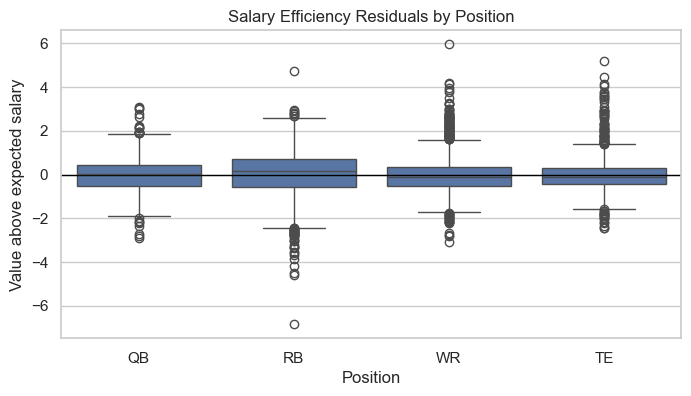

In [7]:
position_summary = (
    salary_efficiency[salary_efficiency["has_salary"]]
    .groupby("position", as_index=False)
    .agg(
        player_seasons=("player_id", "count"),
        median_salary_millions=("salary_millions", "median"),
        median_value_score=("value_score", "median"),
        median_value_above_expected_salary=("value_above_expected_salary", "median"),
        high_efficiency_rate=("salary_efficiency_tier", lambda s: (s == "High Efficiency").mean()),
        low_efficiency_rate=("salary_efficiency_tier", lambda s: (s == "Low Efficiency").mean()),
    )
)

display(position_summary.round(3))

plt.figure(figsize=(8, 4))
sns.boxplot(
    data=salary_efficiency[salary_efficiency["has_salary"]],
    x="position",
    y="value_above_expected_salary",
    order=["QB", "RB", "WR", "TE"],
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Salary Efficiency Residuals by Position")
plt.xlabel("Position")
plt.ylabel("Value above expected salary")
plt.show()

## Rookie-Contract Style View

A major reason to study salary efficiency is that rookie contracts can create surplus value. I use `years_exp <= 3` as a simple rookie-contract style proxy.

This is imperfect because actual contract status depends on draft round, extensions, fifth-year options, and timing, but it gives a useful first look.

,position,rookie_contract_proxy,player_seasons,median_salary_millions,median_value_score,median_value_above_expected_salary
0,QB,False,309,27.505,-0.158,0.055
1,QB,True,217,4.786,-0.366,-0.021
2,RB,False,410,3.219,-0.007,0.036
3,RB,True,758,1.384,0.127,0.255
4,TE,False,446,5.496,-0.196,-0.126
5,TE,True,566,1.387,-0.272,-0.086
6,WR,False,755,7.034,-0.147,-0.099
7,WR,True,1108,1.424,-0.369,-0.123


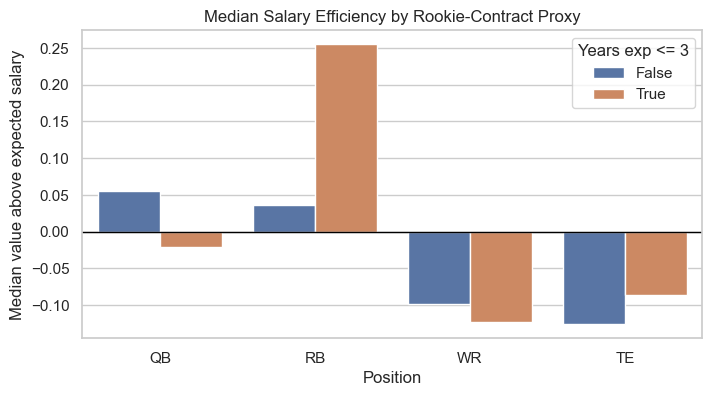

In [8]:
rookie_view = salary_efficiency[salary_efficiency["has_salary"]].copy()
rookie_view["rookie_contract_proxy"] = rookie_view["years_exp"].le(3)

rookie_summary = (
    rookie_view
    .groupby(["position", "rookie_contract_proxy"], as_index=False)
    .agg(
        player_seasons=("player_id", "count"),
        median_salary_millions=("salary_millions", "median"),
        median_value_score=("value_score", "median"),
        median_value_above_expected_salary=("value_above_expected_salary", "median"),
    )
)

display(rookie_summary.round(3))

plt.figure(figsize=(8, 4))
sns.barplot(
    data=rookie_summary,
    x="position",
    y="median_value_above_expected_salary",
    hue="rookie_contract_proxy",
    order=["QB", "RB", "WR", "TE"],
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Median Salary Efficiency by Rookie-Contract Proxy")
plt.xlabel("Position")
plt.ylabel("Median value above expected salary")
plt.legend(title="Years exp <= 3")
plt.show()

## Saved Outputs

The notebook saves salary-efficiency tables under `outputs/tables/`. I am saving the results because these are small, recruiter-friendly artifacts, while the raw contract data stays local and ignored by Git.

In [9]:
for path in sorted(output_dir.glob("salary_efficiency_*.csv")):
    print(path)

/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/salary_efficiency_2016_2025.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/salary_efficiency_by_position.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/salary_efficiency_by_season.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/salary_efficiency_lowest_players.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/salary_efficiency_merge_diagnostics.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/salary_efficiency_top_players.csv


## Methodological Notes

This is a useful first salary-efficiency version, but I would not call it final.

Main strengths:

- The merge uses `gsis_id`, so it avoids most name-matching problems.
- Contract cost is adjusted with `inflated_apy`, which is more comparable across seasons than raw APY.
- The residual approach is better than only using value-per-dollar ratios.

Main limitations:

- `inflated_apy` is not the same as exact season cap hit or cash paid.
- Active contract seasons are inferred from `year_signed` and `years`.
- Restructures, void years, trades, extensions, incentives, dead cap, and guarantees are not fully modeled.
- The residual model is descriptive, not causal.

The next improvement would be to add true season-level cap-hit or cash-paid data, then rerun the same framework with a more precise cost variable.